#  Retail Sales Clustering
## Clustering / Segmentation Modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

rfm = pd.read_csv('rfm_table.csv')
print(rfm.shape)
rfm.head(3)

(3913, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,282,1,77183.60
1,12347.0,86,5,2790.86
2,12348.0,31,4,1797.24


In [2]:
#  Feature Engineering: Log-transform & Scale
rfm_feat = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_feat['Frequency'] = np.log1p(rfm_feat['Frequency'])
rfm_feat['Monetary']  = np.log1p(rfm_feat['Monetary'])

scaler = StandardScaler()
X = scaler.fit_transform(rfm_feat)
print('Scaled shape:', X.shape)

Scaled shape: (3913, 3)


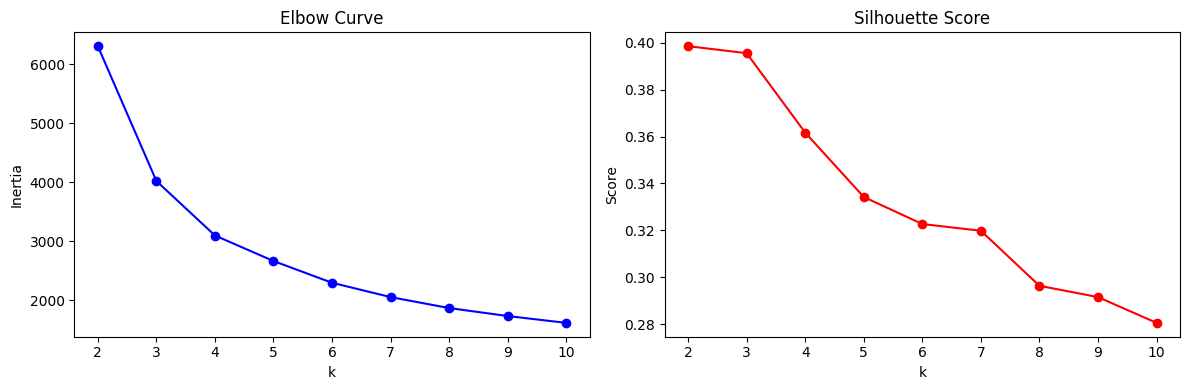

Best k by silhouette: 2


In [3]:
#  Elbow Method
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=100)
plt.show()
print('Best k by silhouette:', K_range[np.argmax(sil_scores)])

In [4]:
#  Final KMeans (k=4)
BEST_K = 4
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = km_final.fit_predict(X)

print('Cluster sizes:')
print(rfm['KMeans_Cluster'].value_counts())

Cluster sizes:
KMeans_Cluster
1    1337
2    1114
0     929
3     533
Name: count, dtype: int64


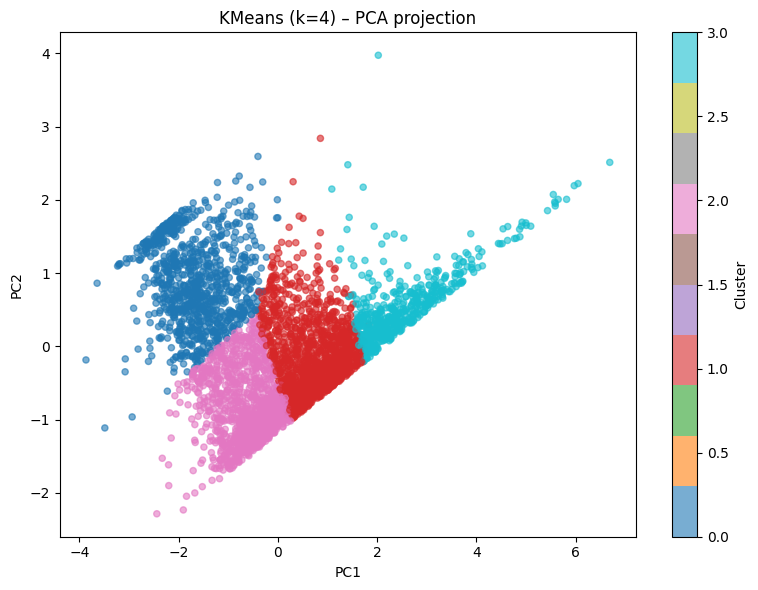

Explained variance: 92.98%


In [5]:
#  PCA 2-D Visualisation
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=rfm['KMeans_Cluster'],
                      cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.title(f'KMeans (k={BEST_K}) – PCA projection')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=100)
plt.show()
print(f'Explained variance: {pca.explained_variance_ratio_.sum():.2%}')

In [6]:
#  DBSCAN (alternative / comparison)
db = DBSCAN(eps=0.5, min_samples=10)
rfm['DBSCAN_Cluster'] = db.fit_predict(X)

n_clusters_db = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
noise = (rfm['DBSCAN_Cluster'] == -1).sum()
print(f'DBSCAN → {n_clusters_db} clusters, {noise} noise points')
print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN → 2 clusters, 81 noise points
DBSCAN_Cluster
 0    2316
 1    1516
-1      81
Name: count, dtype: int64


Cluster Profiles:
                    Recency  Frequency     Monetary
KMeans_Cluster                                    
0               236.926803   1.286329   363.514564
1                52.502618   3.561705  1437.250399
2                57.367145   1.364452   342.387721
3                27.110694  13.583490  8245.926154


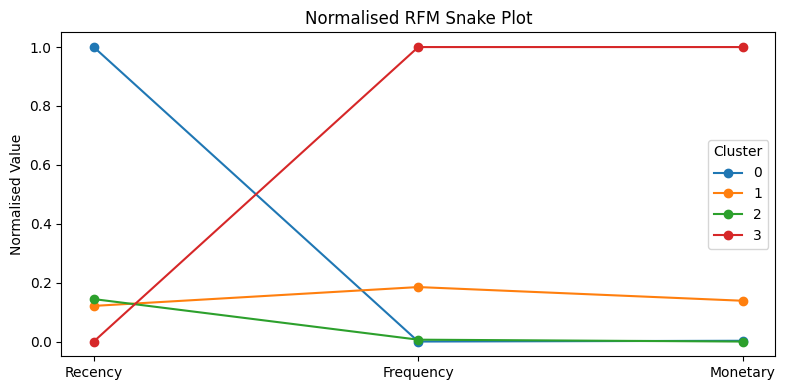

In [7]:
# Cluster Profile: RFM Snake-plot
profile = rfm.groupby('KMeans_Cluster')[['Recency','Frequency','Monetary']].mean()
print('Cluster Profiles:\n', profile)

profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
profile_norm.T.plot(kind='line', marker='o', figsize=(8, 4))
plt.title('Normalised RFM Snake Plot')
plt.ylabel('Normalised Value')
plt.xticks(ticks=range(3), labels=['Recency','Frequency','Monetary'])
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('snake_plot.png', dpi=100)
plt.show()

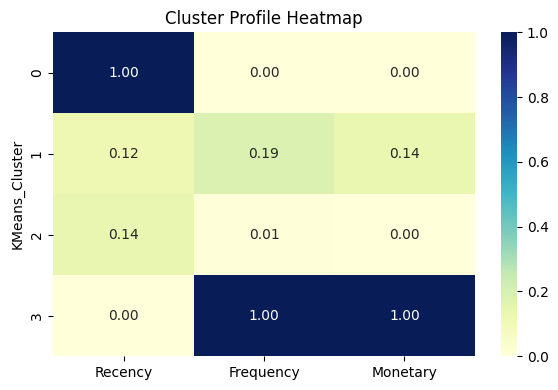

Segment
Champions              1337
Potential Loyalists    1114
At-Risk                 929
Lost/Inactive           533
Name: count, dtype: int64


In [8]:
# Heatmap of cluster profiles
plt.figure(figsize=(6, 4))
sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Cluster Profile Heatmap')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=100)
plt.show()

# Assign business labels
# Adjust mapping after inspecting profile output above
label_map = {
    0: 'At-Risk',
    1: 'Champions',
    2: 'Potential Loyalists',
    3: 'Lost/Inactive'
}
rfm['Segment'] = rfm['KMeans_Cluster'].map(label_map)
print(rfm['Segment'].value_counts())

In [9]:
#  Save model results
rfm.to_csv('rfm_clustered.csv', index=False)
print('Saved as rfm_clustered.csv')

Saved as rfm_clustered.csv
